# DATA-445 In-Class Assignment 2

Consider the `Real_Estate.csv` data file posted on Blackboard (under the In-Class 2 assignment link). This file contains information related to 414 houses. The goal is to predict the house price of unit area.

## 1. (3 points) Using the pandas library, read the csv data file and create a data-frame called `house_price`.

In [7]:
import pandas as pd
import numpy as np

house_price = pd.read_csv('Real_Estate.csv')
house_price.head()

,No,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 2. (3 points) Drop the `No` column.

In [8]:
#dropping the No column since it is not needed
house_price = house_price.drop(columns=['No'],axis=1)
house_price.head()

,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 3. (4 points) Create a scatter plot of `house_age` and `house_price_of_unit_area`. Describe the plot.

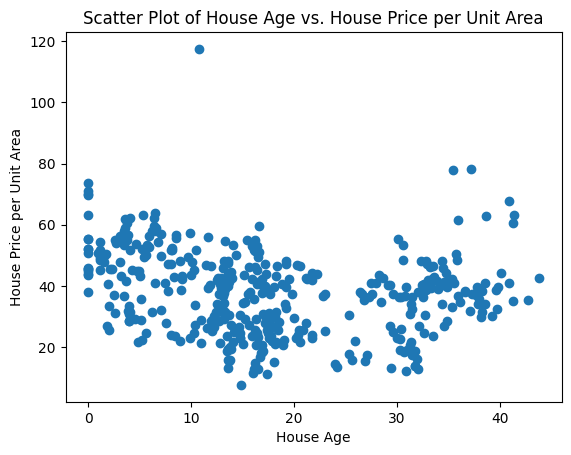

In [11]:
#creating a scatter plot of the house_age and the house_price_of_unit_area
import matplotlib.pyplot as plt

plt.scatter(house_price['house_age'], house_price['house_price_of_unit_area'])
plt.xlabel('House Age')
plt.ylabel('House Price per Unit Area')
plt.title('Scatter Plot of House Age vs. House Price per Unit Area')
plt.show()

from the above scatter plot we see that there are two groups of houses, newer(less than about 25 years old), and older homes(more than or equal to about 25 years old). The house price of the unit area of each of those groups behave different (probably becuiase of location and or other features attached to the houses.)

## 4. (4 points) Create a scatter plot of `distance_to_the_nearest_MRT_station` and `house_price_of_unit_area`. Describe the plot.

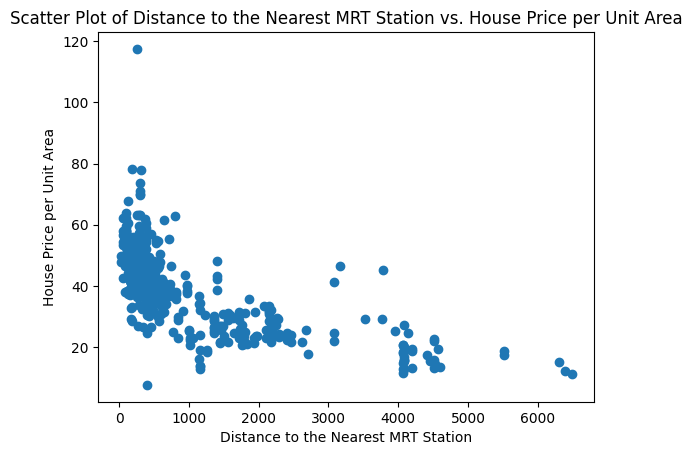

In [12]:
#creating a scatter plot if the distance to the nearest MRT station and the house_price_of_unit_area
plt.scatter(house_price['distance_to_the_nearest_MRT_station'], house_price['house_price_of_unit_area'])
plt.xlabel('Distance to the Nearest MRT Station')
plt.ylabel('House Price per Unit Area')
plt.title('Scatter Plot of Distance to the Nearest MRT Station vs. House Price per Unit Area')
plt.show()

From the plot above we can see that the closer you are in area to the MRT station the more expensive on average that a house would be.

## 5. (5 points) Build a linear regression model

Input variables: `house_age`, `distance_to_the_nearest_MRT_station`, `number_of_convenience_stores`, `latitude`, and `longitude`.

Target variable: `house_price_of_unit_area`.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# setting the input variables
X = house_price [[
    "house_age",
    "distance_to_the_nearest_MRT_station",
    "number_of_convenience_stores",
    "latitude",
    "longitude"
]]

Y = house_price[["house_price_of_unit_area"]]

#creating the linear regression model
model = LinearRegression()
model.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 6. (3 points) Using the model from part 5, predict the house price of unit area

For a house with: `house_age = 5`, `distance_to_the_nearest_MRT_station = 500`, `number_of_convenience_stores = 3`, `latitude = 24.98`, and `longitude = 121.49`.

In [ ]:
#values for the house we want to predict
new_data =pd.DataFrame({
    "house_age": [5],
    "distance_to_the_nearest_MRT_station": [500],
    "number_of_convenience_stores": [3],
    "latitude": [24.98],
    "longitude": [121.49]
})

new_data

,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude
0,5,500,5,24.98,121.49


In [16]:
predicted_price = model.predict(new_data)
print(predicted_price[0])

[47.88583817]
